# Week 2: Hidden Anomalies in Observed Data

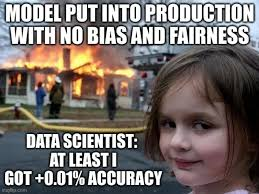

You receive three CSV files from a new collection of the same ACSIncome task:

- `week2_train_observed.csv`
- `week2_validation_observed.csv`
- `week2_test_features.csv`

You have received three new CSV files from a recent data collection effort for the ACSIncome task. However, this data was collected "in the wild" and has not been vetted. It may contain undocumented data-quality issues, distribution shifts, or inconsistent labels. 

You are **not** told whether a problem exists, what features are affected, or what caused the issues. Your task is to act and audit: you must explore the data, design robust checks to uncover issues, and critically interpret your findings to hypothesize what might be going wrong in the data pipeline. 

Do not jump directly to mitigation. A good audit strictly distinguishes between *observed evidence*, *hypotheses*, and *conclusions*.

In [ ]:
%pip -q install fairlearn cleanlab scikit-learn pandas matplotlib seaborn

In [7]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp

RANDOM_STATE = 42
DATA_DIR = Path("~/Documents/DTU/Fall2026/02517/Responsible_AI/data2")  # TODO: change if necessary

# In Colab you may instead upload the CSVs:
# from google.colab import files
# files.upload()

train = pd.read_csv(DATA_DIR / "week2_train_observed.csv")
validation = pd.read_csv(DATA_DIR / "week2_validation_observed.csv")
test_features = pd.read_csv(DATA_DIR / "week2_test_features.csv")

print(train.shape, validation.shape, test_features.shape)
display(train.head())

(18000, 15) (6000, 15) (6000, 14)


,row_id,AGEP,COW,SCHL,MAR,OCCP,POBP,RELP,WKHP,SEX,RAC1P,SEX_group,RACE_group,SURVEY_BATCH,income_observed
0,0,23.0,1.0,20.0,5.0,9130.0,48.0,2.0,40.0,1.0,1.0,Male,White,B04,0
1,1,57.0,1.0,21.0,1.0,3255.0,301.0,1.0,35.0,2.0,1.0,Female,White,B06,1
2,2,29.0,1.0,21.0,1.0,6800.0,6.0,0.0,48.0,1.0,1.0,Male,White,B02,1
3,3,42.0,6.0,17.0,1.0,6200.0,313.0,1.0,40.0,1.0,1.0,Male,White,B04,0
4,4,67.0,1.0,20.0,1.0,3601.0,48.0,0.0,6.0,2.0,2.0,Female,Black,B08,0


Hints: Design checks for schema, missingness, duplicates, impossible values, group sizes, target prevalence, and feature drift. Do not assume a column is safe merely because its name sounds administrative.

In [9]:
# TODO: implement a reusable dataset summary.
def dataset_summary(df, label=None, name=""):
    #print shape 
    print(f"=== {name} ===")
    print(f"Shape: {df.shape}")
    
    # Schema - print column names and dtypes
    print(f"\nColumns:\n{df.columns.tolist()}")
    print(f"\nDtypes:\n{df.dtypes}")
    
    # Duplicates
    n_dup = df.duplicated().sum()
    print(f"\nFull-row duplicates: {n_dup}")
    if "row_id" in df.columns:
        n_dup_no_id = df.drop(columns="row_id").duplicated().sum()
        print(f"Duplicates excluding row_id: {n_dup_no_id}")
    
    # Missingness only NA values
    print(f"\nMissing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
    
    # Impossible values for known numeric columns (cannot be negative or exceed reasonable limits)
    if "AGEP" in df.columns: # age cannot be negative or exceed 120
        print(f"\nAGEP range: {df['AGEP'].min()} - {df['AGEP'].max()}")
    if "WKHP" in df.columns: # work hours per week cannot be negative or exceed 168
        print(f"WKHP range: {df['WKHP'].min()} - {df['WKHP'].max()}")
    
    # Group sizes
    for group_col in ["SEX_group", "RACE_group", "SURVEY_BATCH"]:
        if group_col in df.columns:
            print(f"\n{group_col} counts:\n{df[group_col].value_counts()}")
    
    # Label distribution, overall and by group
    if label and label in df.columns:
        print(f"\nOverall {label} prevalence:\n{df[label].value_counts(normalize=True)}")
        for group_col in ["SEX_group", "RACE_group"]: #check specific sensitive groups for label prevalence
            if group_col in df.columns:
                print(f"\n{label} prevalence by {group_col}:")
                print(df.groupby(group_col)[label].mean())


# Check for any specific extreme or frequent values in numeric columns - which is not defined but not NA value
def flag_extreme_or_frequent_values(df, top_n=3):
    for col in df.select_dtypes(include=np.number).columns:
        print(f"\n{col}: min={df[col].min()}, max={df[col].max()}")
        top_vals = df[col].value_counts().head(top_n)
        print(f"Most common values:\n{top_vals}")

# TODO: compare train, validation, and test feature distributions.
def compare_distributions(df1, df2, name1="train", name2="validation"):
    numeric_cols = df1.select_dtypes(include=np.number).columns
    categorical_cols = df1.select_dtypes(exclude=np.number).columns
    
    print(f"--- Numeric drift ({name1} vs {name2}) ---")
    for col in numeric_cols:
        if col in df2.columns and col != "row_id":
            stat, p = ks_2samp(df1[col].dropna(), df2[col].dropna())
            flag = " <-- possible drift" if p < 0.01 else ""
            print(f"{col}: KS stat={stat:.3f}, p={p:.4f}{flag}")
    
    print(f"\n--- Categorical drift ({name1} vs {name2}) ---")
    for col in categorical_cols:
        if col in df2.columns:
            t1 = df1[col].value_counts(normalize=True)
            t2 = df2[col].value_counts(normalize=True)
            combined = pd.concat([t1, t2], axis=1, keys=[name1, name2]).fillna(0)
            print(f"\n{col}:\n{combined}")
            
# use functions to summarize datasets
dataset_summary(train, label="income_observed", name="Train")
dataset_summary(validation, label="income_observed", name="Validation")
dataset_summary(test_features, label=None, name="Test")  # no label present
flag_extreme_or_frequent_values(train)
flag_extreme_or_frequent_values(validation)
flag_extreme_or_frequent_values(test_features)
compare_distributions(train, validation, name1="train", name2="validation")
compare_distributions(train, test_features, name1="train", name2="test")



=== Train ===
Shape: (18000, 15)

Columns:
['row_id', 'AGEP', 'COW', 'SCHL', 'MAR', 'OCCP', 'POBP', 'RELP', 'WKHP', 'SEX', 'RAC1P', 'SEX_group', 'RACE_group', 'SURVEY_BATCH', 'income_observed']

Dtypes:
row_id               int64
AGEP               float64
COW                float64
SCHL               float64
MAR                float64
OCCP               float64
POBP               float64
RELP               float64
WKHP               float64
SEX                float64
RAC1P              float64
SEX_group              str
RACE_group             str
SURVEY_BATCH           str
income_observed      int64
dtype: object

Full-row duplicates: 0
Duplicates excluding row_id: 12

Missing values:
Series([], dtype: int64)

AGEP range: 17.0 - 92.0
WKHP range: 1.0 - 99.0

SEX_group counts:
SEX_group
Male      9565
Female    8435
Name: count, dtype: int64

RACE_group counts:
RACE_group
White                   14021
Black                    1644
Asian                     924
Other race                

In [22]:
from scipy.stats import chi2_contingency


def label_prevalence_by_batch(df, label="income_observed", name=""):
    """Break down label prevalence by SURVEY_BATCH, and by SURVEY_BATCH x SEX_group."""
    if label not in df.columns or "SURVEY_BATCH" not in df.columns:
        return
    print(f"=== {name}: {label} prevalence by SURVEY_BATCH ===")
    print(df.groupby("SURVEY_BATCH")[label].agg(["mean", "count"]))
    if "SEX_group" in df.columns:
        print(f"\n=== {name}: {label} prevalence by SURVEY_BATCH x SEX_group ===")
        print(df.groupby(["SURVEY_BATCH", "SEX_group"])[label].mean().unstack())


def batch_shift_test(df1, df2, name1="A", name2="B"):
    """Chi-square test: is the SURVEY_BATCH distribution different between two splits?"""
    if "SURVEY_BATCH" not in df1.columns or "SURVEY_BATCH" not in df2.columns:
        return
    c1 = df1["SURVEY_BATCH"].value_counts()
    c2 = df2["SURVEY_BATCH"].value_counts()
    table = pd.concat([c1, c2], axis=1, keys=[name1, name2]).fillna(0)
    chi2, p, dof, _ = chi2_contingency(table.T)
    flag = " <-- significant shift" if p < 0.01 else ""
    print(f"SURVEY_BATCH distribution, {name1} vs {name2}: chi2={chi2:.2f}, dof={dof}, p={p:.2e}{flag}")


# Run the extra checks
label_prevalence_by_batch(train, name="Train")
label_prevalence_by_batch(validation, name="Validation")

batch_shift_test(train, validation, "train", "validation")
batch_shift_test(train, test_features, "train", "test")
batch_shift_test(validation, test_features, "validation", "test")


=== Train: income_observed prevalence by SURVEY_BATCH ===
                  mean  count
SURVEY_BATCH                 
B01           0.591564   1944
B02           0.570922   1974
B03           0.587013   1925
B04           0.339135   2011
B05           0.326905   2074
B06           0.150000   2700
B07           0.143230   2681
B08           0.148272   2691

=== Train: income_observed prevalence by SURVEY_BATCH x SEX_group ===
SEX_group       Female      Male
SURVEY_BATCH                    
B01           0.448052  0.685690
B02           0.426471  0.672712
B03           0.448829  0.687612
B04           0.238095  0.428705
B05           0.217801  0.420018
B06           0.103152  0.200153
B07           0.089781  0.199085
B08           0.092566  0.206217
=== Validation: income_observed prevalence by SURVEY_BATCH ===
                  mean  count
SURVEY_BATCH                 
B01           0.613105    641
B02           0.583871    620
B03           0.593458    642
B04           0.325991    68

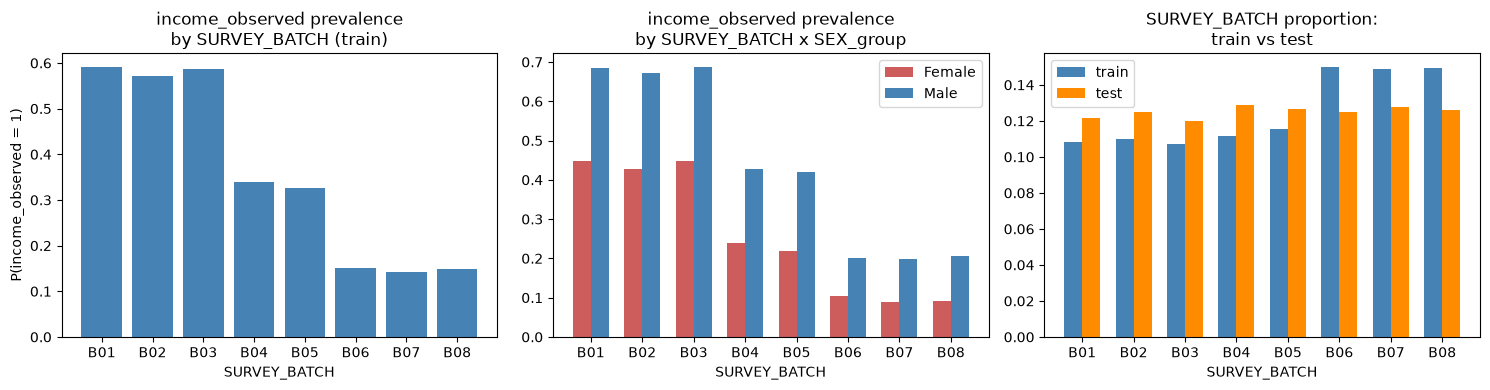

In [23]:
batch_order = sorted(train["SURVEY_BATCH"].unique())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# income_observed prevalence by survey_batch (train)
prevalence = train.groupby("SURVEY_BATCH")["income_observed"].mean().reindex(batch_order)
axes[0].bar(batch_order, prevalence.values, color="steelblue")
axes[0].set_title("income_observed prevalence\nby SURVEY_BATCH (train)")
axes[0].set_ylabel("P(income_observed = 1)")
axes[0].set_xlabel("SURVEY_BATCH")

# same, split by sex_group
prev_by_sex = train.groupby(["SURVEY_BATCH", "SEX_group"])["income_observed"].mean().unstack().reindex(batch_order)
x = np.arange(len(batch_order))
width = 0.35
axes[1].bar(x - width/2, prev_by_sex["Female"].values, width, label="Female", color="indianred")
axes[1].bar(x + width/2, prev_by_sex["Male"].values, width, label="Male", color="steelblue")
axes[1].set_xticks(x)
axes[1].set_xticklabels(batch_order)
axes[1].set_title("income_observed prevalence\nby SURVEY_BATCH x SEX_group")
axes[1].set_xlabel("SURVEY_BATCH")
axes[1].legend()

# survey_batch proportion: train vs test, shows the distribution shift
train_prop = train["SURVEY_BATCH"].value_counts(normalize=True).reindex(batch_order)
test_prop = test_features["SURVEY_BATCH"].value_counts(normalize=True).reindex(batch_order)
axes[2].bar(x - width/2, train_prop.values, width, label="train", color="steelblue")
axes[2].bar(x + width/2, test_prop.values, width, label="test", color="darkorange")
axes[2].set_xticks(x)
axes[2].set_xticklabels(batch_order)
axes[2].set_title("SURVEY_BATCH proportion:\ntrain vs test")
axes[2].set_xlabel("SURVEY_BATCH")
axes[2].legend()

plt.tight_layout()
plt.show()


Hints: Build at least two models, including a simple interpretable baseline. Decide which features belong in the model. Keep `row_id` out of the predictive feature set. Keep sensitive attributes available for auditing even if you exclude them from prediction.

In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score, log_loss, brier_score_loss

LABEL = "income_observed"
ID = "row_id"
SENSITIVE = "SEX_group"

FEATURE_COLUMNS = ["AGEP", "COW", "SCHL", "MAR", "OCCP", "POBP", "RELP", "WKHP"]

NUMERIC_FEATURES = ["AGEP", "WKHP"]
CATEGORICAL_FEATURES = ["COW", "SCHL", "MAR", "RELP"]
HIGH_CARDINALITY = ["OCCP", "POBP"]  # overvej separat behandling, eller inkluder i categorical med håndtering af unseen categories

# TODO: write a model factory that handles numeric and categorical columns.

# a simple model factory that creates a pipeline with preprocessing and logistic regression
def make_model(frame):
    numeric = NUMERIC_FEATURES
    categorical = CATEGORICAL_FEATURES + HIGH_CARDINALITY
    
    preprocessor = ColumnTransformer(transformers=[
        ("num", StandardScaler(), numeric),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical)
    ])
    
    model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(random_state=RANDOM_STATE))
    ])
    return model

# TODO: fit a baseline on observed training labels and evaluate against observed validation labels.
X_train = train[FEATURE_COLUMNS]
y_train = train[LABEL]
X_val = validation[FEATURE_COLUMNS]
y_val = validation[LABEL]

baseline = make_model(train)
baseline.fit(X_train, y_train)

val_pred = baseline.predict(X_val)
val_proba = baseline.predict_proba(X_val)[:, 1]

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_val, val_pred))
print("Balanced accuracy:", balanced_accuracy_score(y_val, val_pred))
print("ROC AUC:", roc_auc_score(y_val, val_proba))
print("Log loss:", log_loss(y_val, val_proba))
print("Brier score:", brier_score_loss(y_val, val_proba))

=== Logistic Regression ===
Accuracy: 0.7801666666666667
Balanced accuracy: 0.7386032937741607
ROC AUC: 0.8495607943320764
Log loss: 0.446348618161646
Brier score: 0.14600615161387742


In [47]:
from sklearn.ensemble import RandomForestClassifier

def make_rf_model(frame):
    numeric = ["AGEP", "WKHP"]
    categorical = ["COW", "SCHL", "MAR", "RELP", "OCCP", "POBP"]
    
    preprocessor = ColumnTransformer(transformers=[
        ("num", StandardScaler(), numeric),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical)
    ])
    
    model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=300, 
            max_depth=None,  # lad træerne vokse frit
            min_samples_leaf=5,  # men undgå overfitting via leaf-size i stedet
            class_weight="balanced",  # kompenser for skæv fordeling
            random_state=RANDOM_STATE
        ))
    ])
    return model

rf_model = make_rf_model(train)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_val)
rf_proba = rf_model.predict_proba(X_val)[:, 1]

print("=== Random Forest ===")
print("Accuracy:", accuracy_score(y_val, rf_pred))
print("Balanced accuracy:", balanced_accuracy_score(y_val, rf_pred))
print("ROC AUC:", roc_auc_score(y_val, rf_proba))
print("Log loss:", log_loss(y_val, rf_proba))
print("Brier score:", brier_score_loss(y_val, rf_proba))

=== Random Forest ===
Accuracy: 0.747
Balanced accuracy: 0.7569894223189221
ROC AUC: 0.8348591556327514
Log loss: 0.5232448912747671
Brier score: 0.1740330933027339


### With Survey-Batch

In [61]:
from sklearn.ensemble import RandomForestClassifier

FEATURE_COLUMNS = ["AGEP", "COW", "SCHL", "MAR", "OCCP", "POBP", "RELP", "WKHP", "SURVEY_BATCH", "SEX_group", "RACE_group"]

NUMERIC_FEATURES = ["AGEP", "WKHP"]
CATEGORICAL_FEATURES = ["COW", "SCHL", "MAR", "RELP", "SURVEY_BATCH", "SEX_group", "RACE_group"]
HIGH_CARDINALITY = ["OCCP", "POBP"]

def make_rf_model(frame):
    numeric = NUMERIC_FEATURES
    categorical = CATEGORICAL_FEATURES + HIGH_CARDINALITY
    
    preprocessor = ColumnTransformer(transformers=[
        ("num", StandardScaler(), numeric),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical)
    ])
    
    model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=300, 
            max_depth=None,  # lad træerne vokse frit
            min_samples_leaf=5,  # men undgå overfitting via leaf-size i stedet
            class_weight="balanced",  # kompenser for skæv fordeling
            random_state=RANDOM_STATE
        ))
    ])
    return model

X_train = train[FEATURE_COLUMNS]
y_train = train[LABEL]
X_val = validation[FEATURE_COLUMNS]
y_val = validation[LABEL]

rf_model = make_rf_model(train)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_val)
rf_proba = rf_model.predict_proba(X_val)[:, 1]

print("=== Random Forest (with SURVEY_BATCH, SEX_group, RACE_group) ===")
print("Accuracy:", accuracy_score(y_val, rf_pred))
print("Balanced accuracy:", balanced_accuracy_score(y_val, rf_pred))
print("ROC AUC:", roc_auc_score(y_val, rf_proba))
print("Log loss:", log_loss(y_val, rf_proba))
print("Brier score:", brier_score_loss(y_val, rf_proba))

=== Random Forest (with SURVEY_BATCH, SEX_group, RACE_group) ===
Accuracy: 0.8061666666666667
Balanced accuracy: 0.8085027591237305
ROC AUC: 0.8881798520312872
Log loss: 0.4721269155956607
Brier score: 0.15081958403362355


### RF Feature Importance

In [62]:
import re
import pandas as pd

feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()
importances = rf_model.named_steps["classifier"].feature_importances_

# map each one-hot column back to its original source column
def source_column(name):
    name = re.sub(r"^(num|cat)__", "", name)
    for col in FEATURE_COLUMNS:
        if name == col or name.startswith(col + "_"):
            return col
    return name

imp_df = pd.DataFrame({"feature": feature_names, "importance": importances})
imp_df["source_column"] = imp_df["feature"].map(source_column)

agg_importance = imp_df.groupby("source_column")["importance"].sum().sort_values(ascending=False)
print(agg_importance)

source_column
SURVEY_BATCH    0.223648
SCHL            0.139664
WKHP            0.108547
SEX_group       0.098255
OCCP            0.094386
MAR             0.093332
RELP            0.091587
AGEP            0.082825
POBP            0.038863
RACE_group      0.014717
COW             0.014176
Name: importance, dtype: float64


Compute overall and group-specific utility, selection rate, TPR, FPR, PPV, NPV, equalized-odds components, and probability metrics. Report counts and uncertainty. Explicitly label every result as being evaluated against $Y^{obs}$.

In [46]:
from fairlearn.metrics import MetricFrame, selection_rate, count, equalized_odds_difference
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score

FEATURE_COLUMNS = ["AGEP", "COW", "SCHL", "MAR", "OCCP", "POBP", "RELP", "WKHP"]

NUMERIC_FEATURES = ["AGEP", "WKHP"]
CATEGORICAL_FEATURES = ["COW", "SCHL", "MAR", "RELP"]

# precision score = PPV and recall = TPR

def true_positive_rate(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    return tp / (tp + fn) if (tp + fn) > 0 else np.nan

def false_positive_rate(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    return fp / (fp + tn) if (fp + tn) > 0 else np.nan

def positive_predictive_value(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    return tp / (tp + fp) if (tp + fp) > 0 else np.nan

def negative_predictive_value(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    return tn / (tn + fn) if (tn + fn) > 0 else np.nan

metrics = {
    "selection_rate": selection_rate,
    "count": count,
    "TPR": true_positive_rate,
    "FPR": false_positive_rate,
    "PPV": positive_predictive_value,
    "NPV": negative_predictive_value,
    "accuracy": accuracy_score,
}

# --- Predictions (genberegnes her for at sikre de findes uanset cellerækkefølge) ---
X_val = validation[FEATURE_COLUMNS]
y_val = validation[LABEL]

lr_pred = baseline.predict(X_val)
rf_pred = rf_model.predict(X_val)

# --- MetricFrame by SEX_group ---
mf_lr_sex = MetricFrame(
    metrics=metrics,
    y_true=y_val,
    y_pred=lr_pred,
    sensitive_features=validation["SEX_group"]
)
print("=== Logistic Regression by SEX_group (evaluated against Y_obs) ===")
print(mf_lr_sex.by_group)

mf_rf_sex = MetricFrame(
    metrics=metrics,
    y_true=y_val,
    y_pred=rf_pred,
    sensitive_features=validation["SEX_group"]
)
print("\n=== Random Forest by SEX_group (evaluated against Y_obs) ===")
print(mf_rf_sex.by_group)

# --- Equalized odds difference (separat, ikke i MetricFrame) ---
eo_diff_lr = equalized_odds_difference(y_val, lr_pred, sensitive_features=validation["SEX_group"])
eo_diff_rf = equalized_odds_difference(y_val, rf_pred, sensitive_features=validation["SEX_group"])

print(f"\nEqualized odds difference (LR, SEX_group): {eo_diff_lr:.4f}")
print(f"Equalized odds difference (RF, SEX_group): {eo_diff_rf:.4f}")

# --- Intersection: SEX_group x RACE_group ---
intersection = validation["SEX_group"] + " / " + validation["RACE_group"]

mf_lr_intersect = MetricFrame(
    metrics=metrics,
    y_true=y_val,
    y_pred=lr_pred,
    sensitive_features=intersection
)
print("\n=== Logistic Regression by SEX x RACE (evaluated against Y_obs) ===")
print(mf_lr_intersect.by_group)

mf_rf_intersect = MetricFrame(
    metrics=metrics,
    y_true=y_val,
    y_pred=rf_pred,
    sensitive_features=intersection
)
print("\n=== Random Forest by SEX x RACE (evaluated against Y_obs) ===")
print(mf_rf_intersect.by_group)

eo_diff_lr_intersect = equalized_odds_difference(y_val, lr_pred, sensitive_features=intersection)
eo_diff_rf_intersect = equalized_odds_difference(y_val, rf_pred, sensitive_features=intersection)

print(f"\nEqualized odds difference (LR, SEX x RACE): {eo_diff_lr_intersect:.4f}")
print(f"Equalized odds difference (RF, SEX x RACE): {eo_diff_rf_intersect:.4f}")

=== Logistic Regression by SEX_group (evaluated against Y_obs) ===
           selection_rate   count       TPR       FPR       PPV       NPV  \
SEX_group                                                                   
Female           0.222617  2812.0  0.512821  0.139854  0.511182  0.860933   
Male             0.359787  3188.0  0.658466  0.131229  0.793374  0.768741   

           accuracy  
SEX_group            
Female     0.783073  
Male       0.777604  

=== Random Forest by SEX_group (evaluated against Y_obs) ===
           selection_rate   count       TPR       FPR       PPV       NPV  \
SEX_group                                                                   
Female           0.173898  2812.0  0.426282  0.101920  0.543967  0.845889   
Male             0.256274  3188.0  0.499276  0.070321  0.844553  0.708140   

           accuracy  
SEX_group            
Female     0.793385  
Male       0.743099  

Equalized odds difference (LR, SEX_group): 0.1456
Equalized odds difference 

In [63]:
train["SEX_RACE"] = train["SEX_group"] + " / " + train["RACE_group"]

group_sizes_all = train["SEX_RACE"].value_counts()
big_groups = group_sizes_all[group_sizes_all >= 30].index
sub = train[train["SEX_RACE"].isin(big_groups)]

counts = pd.crosstab(sub["SURVEY_BATCH"], sub["SEX_RACE"])
# print(counts)

props_by_group = pd.crosstab(sub["SURVEY_BATCH"], sub["SEX_RACE"], normalize="columns")
# print((props_by_group * 100).round(1))


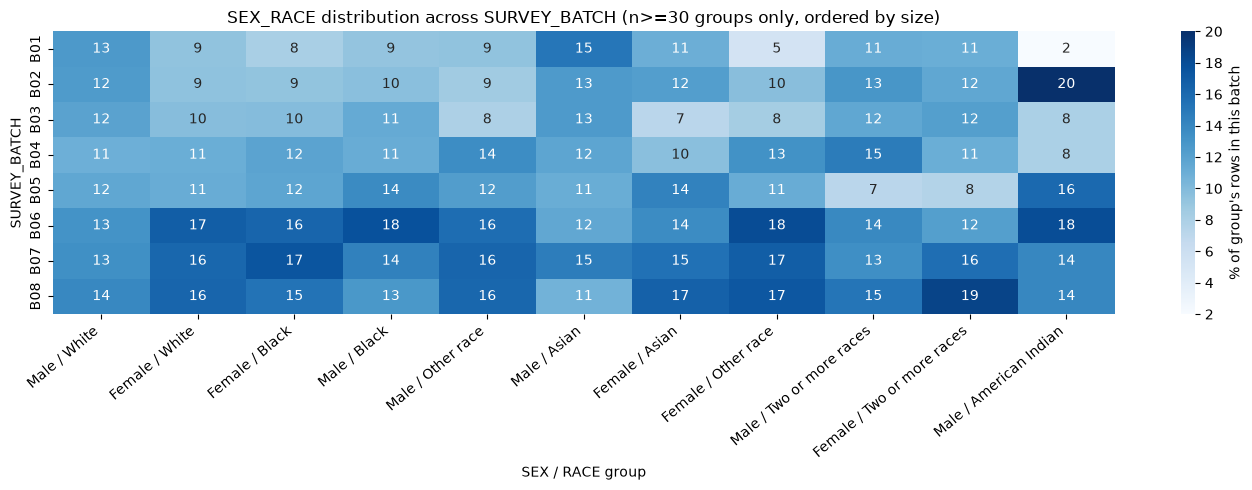

Group sizes (n>=30 only):
SEX_RACE
Male / White                  7533
Female / White                6488
Female / Black                 894
Male / Black                   750
Male / Other race              502
Male / Asian                   477
Female / Asian                 447
Female / Other race            393
Male / Two or more races       224
Female / Two or more races     172
Male / American Indian          50
Name: count, dtype: int64


In [64]:
# Heatmap: % of each SEX_RACE group's rows falling in each SURVEY_BATCH.
# Restricted to the n>=30 groups from the cell above

batch_order = sorted(train["SURVEY_BATCH"].unique())
group_sizes = sub["SEX_RACE"].value_counts()  # already restricted to n>=30
group_order = group_sizes.index.tolist()  # biggest groups first

heat_data = (props_by_group.reindex(index=batch_order, columns=group_order) * 100)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(heat_data, annot=True, fmt=".0f", cmap="Blues",
            cbar_kws={"label": "% of group's rows in this batch"}, ax=ax)
ax.set_title("SEX_RACE distribution across SURVEY_BATCH (n>=30 groups only, ordered by size)")
ax.set_xlabel("SEX / RACE group")
ax.set_ylabel("SURVEY_BATCH")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()

print("Group sizes (n>=30 only):")
print(group_sizes)


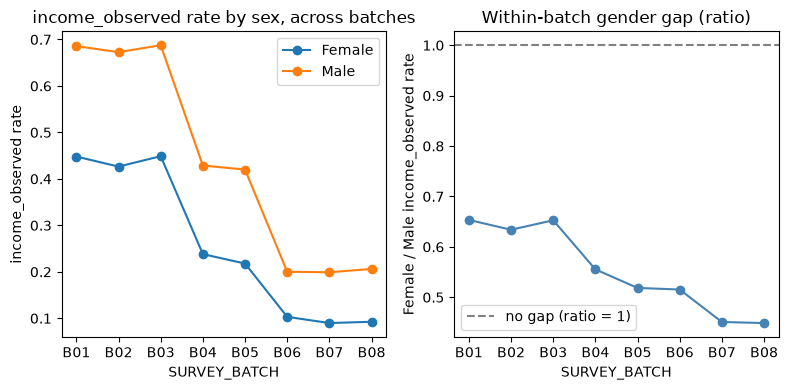

SEX_group       Female      Male
SURVEY_BATCH                    
B01           0.448052  0.685690
B02           0.426471  0.672712
B03           0.448829  0.687612
B04           0.238095  0.428705
B05           0.217801  0.420018
B06           0.103152  0.200153
B07           0.089781  0.199085
B08           0.092566  0.206217
SURVEY_BATCH
B01    0.653432
B02    0.633958
B03    0.652735
B04    0.555382
B05    0.518552
B06    0.515364
B07    0.450969
B08    0.448875
dtype: float64


In [88]:

rate_by_batch_sex = train.groupby(["SURVEY_BATCH", "SEX_group"])["income_observed"].mean().unstack().reindex(batch_order)
fm_ratio = rate_by_batch_sex["Female"] / rate_by_batch_sex["Male"]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Panel 1: absolute income_observed rate for each sex, across batches
axes[0].plot(batch_order, rate_by_batch_sex["Female"], marker="o", label="Female", color="tab:blue")
axes[0].plot(batch_order, rate_by_batch_sex["Male"], marker="o", label="Male", color="tab:orange")
axes[0].set_ylabel("income_observed rate")
axes[0].set_xlabel("SURVEY_BATCH")
axes[0].set_title("income_observed rate by sex, across batches")
axes[0].legend()

# Panel 2: Female/Male ratio -- isolates whether the RELATIVE gap also changes
axes[1].plot(batch_order, fm_ratio.values, marker="o", color="steelblue")
axes[1].axhline(1.0, linestyle="--", color="gray", label="no gap (ratio = 1)")
axes[1].set_ylabel("Female / Male income_observed rate")
axes[1].set_xlabel("SURVEY_BATCH")
axes[1].set_title("Within-batch gender gap (ratio)")
axes[1].legend()

plt.tight_layout()
plt.show()

print(rate_by_batch_sex)
print(fm_ratio)

In [87]:
n1 = (0.448-0.096) / 0.448 * 100
n2 = (0.68569 - 0.206217) / 0.68569 * 100

print(n1, n2)

78.57142857142857 69.92562236579212


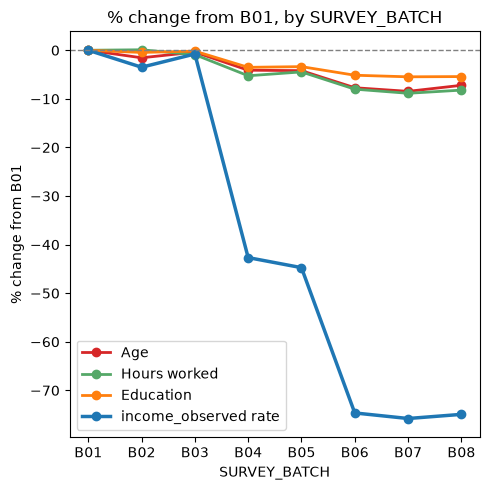

In [86]:
cols = ["AGEP", "WKHP", "SCHL"]
means_by_batch = train.groupby("SURVEY_BATCH")[cols + ["income_observed"]].mean().reindex(batch_order)

# express everything as % change from B01, so all four series are comparable on one axis
pct_change = (means_by_batch / means_by_batch.iloc[0] - 1) * 100

fig, ax = plt.subplots(figsize=(5, 5))
colors = {"AGEP": "tab:red", "WKHP": "#55A868", "SCHL": "tab:orange", "income_observed": "tab:blue"}
labels = {"AGEP": "Age", "WKHP": "Hours worked", "SCHL": "Education", "income_observed": "income_observed rate"}

for col in cols:
    ax.plot(batch_order, pct_change[col], marker="o", color=colors[col], label=labels[col], linewidth=2)

ax.plot(batch_order, pct_change["income_observed"], marker="o", color=colors["income_observed"],
        label=labels["income_observed"], linewidth=2.5)

ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.set_ylabel("% change from B01")
ax.set_xlabel("SURVEY_BATCH")
ax.set_title("% change from B01, by SURVEY_BATCH")
ax.legend()
plt.tight_layout()
plt.show()

### Mitigating observed bias

Hint: The Threshold Optimizer method in FairLearn (https://fairlearn.org/v0.5.0/api_reference/fairlearn.postprocessing.html) can be used to enforce e.g. the Equalized Odds criterion -- we have learned about how it works in week 2. But for now, apply the Threshold_Optimizer to mitigate bias according to one of your chosen criteria (using the "constraints" option). Repeat your fairness diagnostics for the updated model. Did the mitigation make the model more fair in all respects?

Calibration must name its target label. Compare group reliability curves and Brier scores against `income_observed`. Inspect whether apparent calibration differs by group and by score range.

Any more mitigation stratergies you could think of? Do they work on the observed data? 

In [ ]:
from fairlearn.postprocessing import ThresholdOptimizer

sensitive_val = validation["SEX_group"]

post_lr = ThresholdOptimizer(
    estimator=baseline,
    constraints="equalized_odds",
    predict_method="predict_proba",
    prefit=True,
)

post_lr.fit(X_val, y_val, sensitive_features=sensitive_val)

lr_pred_mitigated = post_lr.predict(X_val, sensitive_features=sensitive_val)

mf_lr_mitigated = MetricFrame(
    metrics=metrics,
    y_true=y_val,
    y_pred=lr_pred_mitigated,
    sensitive_features=sensitive_val,
)
print("=== Logistic Regression + ThresholdOptimizer (equalized_odds) by SEX_group ===")
print(mf_lr_mitigated.by_group)

eo_diff_lr_mitigated = equalized_odds_difference(y_val, lr_pred_mitigated, sensitive_features=sensitive_val)
print(f"\nEqualized odds difference (LR + mitigation, SEX_group): {eo_diff_lr_mitigated:.4f}")
print(f"(before mitigation, for comparison: {eo_diff_lr:.4f})")

# Also check what happened to selection_rate parity and to accuracy -- the
# hint asks "did the mitigation make the model more fair in ALL respects?"
# Equalized odds improving does not guarantee demographic parity or accuracy
# also improved -- compare mf_lr_mitigated.by_group against mf_lr_sex.by_group
# from the cell above.


=== Logistic Regression + ThresholdOptimizer (equalized_odds) by SEX_group ===
           selection_rate   count       TPR       FPR       PPV       NPV  \
SEX_group                                                                   
Female           0.268137  2812.0  0.604167  0.172303  0.500000  0.879981   
Male             0.361355  3188.0  0.605644  0.174419  0.726562  0.732318   

           accuracy  
SEX_group            
Female     0.778094  
Male       0.730238  

Equalized odds difference (LR + mitigation, SEX_group): 0.0021
(before mitigation, for comparison: 0.1456)


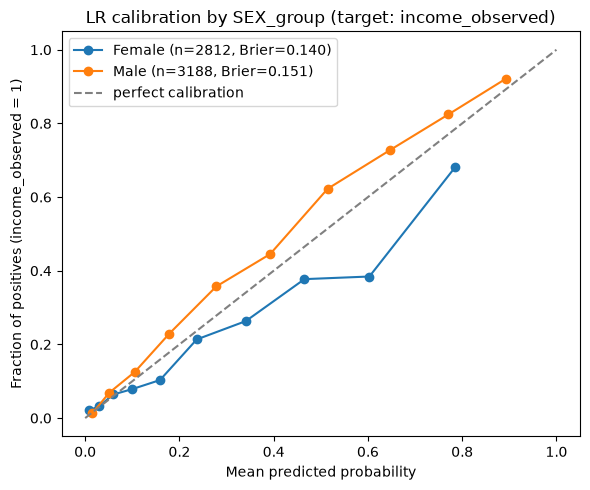

In [ ]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

lr_proba = baseline.predict_proba(X_val)[:, 1]

fig, ax = plt.subplots(figsize=(6, 5))
for group in sensitive_val.unique():
    mask = (sensitive_val == group).to_numpy()
    n_group = mask.sum()
    
    n_bins = 10 if n_group >= 500 else max(3, n_group // 100)
    frac_pos, mean_pred = calibration_curve(
        y_val[mask], lr_proba[mask], n_bins=n_bins, strategy="quantile"
    )
    brier = brier_score_loss(y_val[mask], lr_proba[mask])
    ax.plot(mean_pred, frac_pos, marker="o", label=f"{group} (n={n_group}, Brier={brier:.3f})")

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="perfect calibration")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives (income_observed = 1)")
ax.set_title("LR calibration by SEX_group (target: income_observed)")
ax.legend()
plt.tight_layout()
plt.show()


## Week 2 : What to think about?

1. Audit plan and model cards for your baselines.
2. Observed-label performance, fairness, and calibration.
3. Label-quality evidence ?
4. Instability evidence?
5. Two competing explanations for your findings.
7. A clear separation between **observed evidence**, **hypothesis**, and **conclusion**.

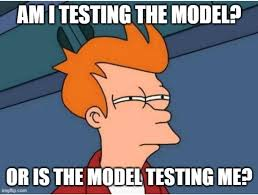

## 📝 Project 1 Submission Guidelines (Week 2 Contribution)

The investigations and hypotheses generated from this Week 2 notebook will form the second major section of your final A0 poster (~ another 1/3 of the poster).

When preparing your poster, ensure this section includes:
* Briefly outline the models and checks you used to establish performance and fairness baselines on the observed (but untrusted (?)) labels.
* *Highlight the most compelling evidence of data labels issue or generalizability issues you discovered (e.g., highly suspicious/unstable features, strange sub-group performances, or findings using popular frameworks).
* Present your strongest hypotheses explaining *why* these anomalies exist in the data. Clearly separate your observed data evidence from your conclusions about what real-world issues (such as systemic biases or collection flaws) might be causing them.
